# Homework Report – Programming Assigment 3

## Purpose

The purpose of this assignment is to apply classical AI search methods to two different domains:

- **Problem 3.7** in the 3rd edition / **Problem 3.9** in some repository references: shortest path in a plane with convex polygonal obstacles.
- **Problem 3.9** in the 3rd edition / **Problem 3.11** in some repository references: missionaries and cannibals.

## Key Questions

1. How should each problem be represented as a search problem with states, actions, results, goal test, and path cost?
2. Which search algorithms are appropriate for each domain, and why?
3. What do the results show about optimality, repeated states, and the usefulness of informed search?

## Concepts

The notebook uses the following AI concepts throughout:

- state representation
- state space and search graph
- successor / action function
- goal test
- path cost
- repeated-state checking
- breadth-first search
- uniform-cost search
- greedy best-first search
- A* search
- admissible geometric heuristic

## Information Gathered

The assignment statement explains that the repository numbering differs from the 3rd edition numbering. The attached pages provide the exact 3rd-edition statements for Problems 3.7 and 3.9.

## Experiment Setup and Tools

- The notebook is **self-contained**.
- It uses **Python only** and standard libraries plus `matplotlib` for optional plots.
- The code follows the AIMA search style: explicit state representation, successor function, path cost, goal test, and graph search.
- The obstacle-domain figure is implemented as a **numerical scene inspired by the textbook illustration**, because the textbook figure does not provide exact coordinates.


In [ ]:
from __future__ import annotations

from collections import defaultdict, deque
from dataclasses import dataclass, field
from heapq import heappop, heappush
from itertools import combinations
from math import hypot
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple

Point = Tuple[float, float]
State = Tuple[int, int, int]

## Reusable search code

The next cell defines small reusable search helpers used in both problems.

In [ ]:
@dataclass(order=True)
class PrioritizedItem:
    priority: float
    count: int
    node: object = field(compare=False)

@dataclass
class SearchNode:
    state: object
    parent: Optional["SearchNode"] = None
    action: Optional[object] = None
    path_cost: float = 0.0
    depth: int = 0

    def path(self) -> List["SearchNode"]:
        node: Optional["SearchNode"] = self
        result: List["SearchNode"] = []
        while node is not None:
            result.append(node)
            node = node.parent
        return list(reversed(result))


def reconstruct_states(node: SearchNode) -> List[object]:
    return [n.state for n in node.path()]


def breadth_first_graph_search(
    initial_state: object,
    goal_test: Callable[[object], bool],
    actions: Callable[[object], Iterable[object]],
    result: Callable[[object, object], object],
) -> Tuple[Optional[SearchNode], Dict[str, int]]:
    root = SearchNode(initial_state)
    if goal_test(initial_state):
        return root, {"expanded": 0, "generated": 1}

    frontier = deque([root])
    frontier_states = {initial_state}
    explored = set()
    expanded = 0
    generated = 1

    while frontier:
        node = frontier.popleft()
        frontier_states.discard(node.state)
        if node.state in explored:
            continue
        explored.add(node.state)
        expanded += 1

        for action in actions(node.state):
            child_state = result(node.state, action)
            if child_state in explored or child_state in frontier_states:
                continue
            child = SearchNode(
                state=child_state,
                parent=node,
                action=action,
                path_cost=node.path_cost + 1,
                depth=node.depth + 1,
            )
            generated += 1
            if goal_test(child_state):
                return child, {"expanded": expanded, "generated": generated}
            frontier.append(child)
            frontier_states.add(child_state)

    return None, {"expanded": expanded, "generated": generated}


def best_first_graph_search(
    initial_state: object,
    goal_test: Callable[[object], bool],
    actions: Callable[[object], Iterable[object]],
    result: Callable[[object, object], object],
    step_cost: Callable[[object, object, object], float],
    f: Callable[[SearchNode], float],
) -> Tuple[Optional[SearchNode], Dict[str, float]]:
    counter = 0
    root = SearchNode(initial_state)
    frontier: List[PrioritizedItem] = [PrioritizedItem(f(root), counter, root)]
    best_cost: Dict[object, float] = {initial_state: 0.0}
    expanded = 0
    generated = 1

    while frontier:
        item = heappop(frontier)
        node = item.node
        if node.path_cost > best_cost.get(node.state, float("inf")):
            continue

        if goal_test(node.state):
            return node, {"expanded": expanded, "generated": generated, "cost": node.path_cost}

        expanded += 1
        for action in actions(node.state):
            child_state = result(node.state, action)
            new_cost = node.path_cost + step_cost(node.state, action, child_state)
            if new_cost >= best_cost.get(child_state, float("inf")):
                continue

            best_cost[child_state] = new_cost
            counter += 1
            child = SearchNode(
                state=child_state,
                parent=node,
                action=action,
                path_cost=new_cost,
                depth=node.depth + 1,
            )
            generated += 1
            heappush(frontier, PrioritizedItem(f(child), counter, child))

    return None, {"expanded": expanded, "generated": generated, "cost": float("inf")}


def uniform_cost_search(
    initial_state: object,
    goal_test: Callable[[object], bool],
    actions: Callable[[object], Iterable[object]],
    result: Callable[[object, object], object],
    step_cost: Callable[[object, object, object], float],
) -> Tuple[Optional[SearchNode], Dict[str, float]]:
    return best_first_graph_search(
        initial_state=initial_state,
        goal_test=goal_test,
        actions=actions,
        result=result,
        step_cost=step_cost,
        f=lambda node: node.path_cost,
    )


def astar_search(
    initial_state: object,
    goal_test: Callable[[object], bool],
    actions: Callable[[object], Iterable[object]],
    result: Callable[[object, object], object],
    step_cost: Callable[[object, object, object], float],
    heuristic: Callable[[object], float],
) -> Tuple[Optional[SearchNode], Dict[str, float]]:
    return best_first_graph_search(
        initial_state=initial_state,
        goal_test=goal_test,
        actions=actions,
        result=result,
        step_cost=step_cost,
        f=lambda node: node.path_cost + heuristic(node.state),
    )


def greedy_best_first_search(
    initial_state: object,
    goal_test: Callable[[object], bool],
    actions: Callable[[object], Iterable[object]],
    result: Callable[[object, object], object],
    step_cost: Callable[[object, object, object], float],
    heuristic: Callable[[object], float],
) -> Tuple[Optional[SearchNode], Dict[str, float]]:
    return best_first_graph_search(
        initial_state=initial_state,
        goal_test=goal_test,
        actions=actions,
        result=result,
        step_cost=step_cost,
        f=lambda node: heuristic(node.state),
    )

# Problem 3.7 / 3.9 repository numbering: shortest path with convex polygonal obstacles

The book asks for analysis of parts **(a)** through **(d)**. The obstacle scene is Figure 3.31 on the attached page. 

## Problem Definition

We want to find a shortest collision-free path from the start state **S** to the goal state **G** in a plane containing convex polygonal obstacles.

## Concepts Used

This problem uses:
- continuous versus discrete state spaces
- visibility graphs
- straight-line geometric path cost
- informed search with Euclidean heuristic

## (a) State-space size if states are all points $(x, y)$ in the plane

If the state space contains **all positions in the continuous plane**, then:

- The number of states is **uncountably infinite**.
- The number of possible paths to the goal is also **infinite**.

This makes the raw formulation unusable for ordinary graph search, because search algorithms require a finite or at least effectively enumerable set of states and successors.

## (b) Why an optimal path only needs polygon vertices

For convex polygonal obstacles, any shortest collision-free path is a polygonal chain made of straight segments.

A bend in a shortest path cannot occur in free space:
- If the bend were in empty space, replacing the two adjacent segments by one straight segment would shorten the path.

A bend also need not occur in the middle of an obstacle edge:
- Sliding the contact point along the edge toward a vertex preserves feasibility and cannot increase the path length.

Therefore, a shortest path only needs:
- the **start** point,
- the **goal** point,
- and selected **obstacle vertices**.

This justifies a finite graph formulation called the **visibility graph**.

## Information Gathered for the Model

Because the textbook figure is qualitative and does not provide coordinates, the implementation below uses a hand-built obstacle scene that follows the same idea: a start point, a goal point, and multiple convex polygonal obstacles.

## Experiment Setup / Search Formulation

For the computational experiment, the state space is discretized to:
- **S**
- **G**
- every obstacle vertex

Two nodes are connected if they are mutually visible without crossing an obstacle interior. Edge cost is Euclidean distance.

## (c) Functions needed for search

We need:

- **Initial state**: `S`
- **Goal test**: current vertex is `G`
- **ACTIONS(v)**: return every visible vertex reachable from `v` by a straight line that does not pass through obstacle interiors  
  (following the problem statement, we exclude the two adjacent vertices on the same polygon boundary from the returned actions)
- **RESULT(v, u)**: move from vertex `v` to visible vertex `u`
- **STEP COST(v, u)**: Euclidean distance between the vertices
- **HEURISTIC(v)**: straight-line distance from `v` to `G`

The straight-line heuristic is admissible because no legal path from `v` to `G` can be shorter than the direct Euclidean distance.



In [ ]:

S: Point = (1.0, 1.0)
G: Point = (9.4, 6.6)

polygons: List[List[Point]] = [
    [(2.1, 2.2), (1.9, 4.2), (3.0, 5.8), (3.8, 4.2), (3.2, 1.8)],  # left pentagon
    [(3.9, 2.4), (4.3, 4.5), (4.8, 2.4)],                          # thin triangle
    [(4.9, 4.4), (4.9, 5.7), (5.7, 5.8), (6.2, 5.0)],              # top-center quadrilateral
    [(6.4, 3.0), (6.4, 5.7), (7.8, 5.7), (7.8, 3.0)],              # tall rectangle
    [(8.3, 5.3), (8.9, 5.7), (9.3, 5.2), (9.1, 2.2)],              # top-right quadrilateral
    [(5.7, 3.4), (6.7, 2.3), (6.0, 1.7), (5.8, 2.6)],              # center-lower quadrilateral
    [(7.3, 1.6), (7.3, 2.8), (8.0, 3.5), (8.6, 2.8), (8.6, 1.8), (8.0, 1.3)],  # bottom-right hexagon
]

In [ ]:
def euclidean(a: Point, b: Point) -> float:
    return hypot(a[0] - b[0], a[1] - b[1])


def orient(a: Point, b: Point, c: Point) -> float:
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def on_segment(a: Point, b: Point, p: Point, eps: float = 1e-9) -> bool:
    return (
        abs(orient(a, b, p)) <= eps
        and min(a[0], b[0]) - eps <= p[0] <= max(a[0], b[0]) + eps
        and min(a[1], b[1]) - eps <= p[1] <= max(a[1], b[1]) + eps
    )


def segments_intersect(a: Point, b: Point, c: Point, d: Point, eps: float = 1e-9) -> bool:
    o1 = orient(a, b, c)
    o2 = orient(a, b, d)
    o3 = orient(c, d, a)
    o4 = orient(c, d, b)

    if ((o1 > eps and o2 < -eps) or (o1 < -eps and o2 > eps)) and ((o3 > eps and o4 < -eps) or (o3 < -eps and o4 > eps)):
        return True

    if abs(o1) <= eps and on_segment(a, b, c):
        return True
    if abs(o2) <= eps and on_segment(a, b, d):
        return True
    if abs(o3) <= eps and on_segment(c, d, a):
        return True
    if abs(o4) <= eps and on_segment(c, d, b):
        return True

    return False


def point_in_convex_polygon(p: Point, poly: Sequence[Point], eps: float = 1e-9) -> bool:
    signs = []
    for i in range(len(poly)):
        a = poly[i]
        b = poly[(i + 1) % len(poly)]
        cross = orient(a, b, p)
        if abs(cross) <= eps:
            continue
        signs.append(cross > 0)
    if not signs:
        return True
    return all(signs) or not any(signs)


def proper_segment_hits_polygon_interior(a: Point, b: Point, poly: Sequence[Point]) -> bool:
    # Midpoint test catches segments that run through interior.
    mid = ((a[0] + b[0]) / 2.0, (a[1] + b[1]) / 2.0)
    if point_in_convex_polygon(mid, poly):
        # Ignores midpoint on boundary only if it is on an edge.
        on_boundary = any(on_segment(poly[i], poly[(i + 1) % len(poly)], mid) for i in range(len(poly)))
        if not on_boundary:
            return True

    # If a segment crosses an edge at a non-endpoint, it is blocked.
    for i in range(len(poly)):
        c = poly[i]
        d = poly[(i + 1) % len(poly)]
        if segments_intersect(a, b, c, d):
            shared = {a, b}.intersection({c, d})
            if shared:
                continue
            # Allows the segment to touch the boundary only at one of its own endpoints.
            if on_segment(a, b, c) or on_segment(a, b, d):
                continue
            return True
    return False


vertex_labels: List[str] = ["S", "G"]
vertex_points: Dict[str, Point] = {"S": S, "G": G}
vertex_polygon: Dict[str, Optional[int]] = {"S": None, "G": None}
polygon_neighbors: Dict[str, set[str]] = defaultdict(set)

for poly_idx, poly in enumerate(polygons):
    labels = []
    for i, point in enumerate(poly):
        label = f"P{poly_idx}_{i}"
        labels.append(label)
        vertex_labels.append(label)
        vertex_points[label] = point
        vertex_polygon[label] = poly_idx
    for i, label in enumerate(labels):
        polygon_neighbors[label].add(labels[(i - 1) % len(labels)])
        polygon_neighbors[label].add(labels[(i + 1) % len(labels)])


def visible(u: str, v: str) -> bool:
    a, b = vertex_points[u], vertex_points[v]

    same_poly = vertex_polygon[u] is not None and vertex_polygon[u] == vertex_polygon[v]
    if same_poly and v in polygon_neighbors[u]:
        return True

    for poly in polygons:
        if proper_segment_hits_polygon_interior(a, b, poly):
            return False
    return True


visibility_actions: Dict[str, List[str]] = {
    u: [v for v in vertex_labels if v != u and visible(u, v)]
    for u in vertex_labels
}

len(vertex_labels), sum(len(p) for p in polygons)

(32, 30)

In [ ]:
def vg_goal_test(state: str) -> bool:
    return state == "G"

def vg_actions(state: str) -> Iterable[str]:
    return visibility_actions[state]

def vg_result(state: str, action: str) -> str:
    return action

def vg_step_cost(state: str, action: str, next_state: str) -> float:
    return euclidean(vertex_points[state], vertex_points[next_state])

def vg_heuristic(state: str) -> float:
    return euclidean(vertex_points[state], vertex_points["G"])

### Part (c) in code form

The next cell prints a compact description of the discrete search problem actually used:

- state space size
- node labels
- visibility-based successor sets

In [ ]:
print("Total discrete states in the visibility graph:", len(vertex_labels))
print("States:", vertex_labels)
print()
for state in vertex_labels:
    print(f"{state:>4} -> {visibility_actions[state]}")

Total discrete states in the visibility graph: 32
States: ['S', 'G', 'P0_0', 'P0_1', 'P0_2', 'P0_3', 'P0_4', 'P1_0', 'P1_1', 'P1_2', 'P2_0', 'P2_1', 'P2_2', 'P2_3', 'P3_0', 'P3_1', 'P3_2', 'P3_3', 'P4_0', 'P4_1', 'P4_2', 'P4_3', 'P5_0', 'P5_1', 'P5_2', 'P5_3', 'P6_0', 'P6_1', 'P6_2', 'P6_3', 'P6_4', 'P6_5']

   S -> ['P0_0', 'P0_1', 'P0_4', 'P5_2', 'P5_3', 'P6_0', 'P6_5']
   G -> ['P0_2', 'P2_1', 'P2_2', 'P3_1', 'P3_2', 'P4_0', 'P4_1', 'P4_2', 'P4_3']
P0_0 -> ['S']
P0_1 -> ['S']
P0_2 -> ['G', 'P1_1', 'P2_0', 'P2_1', 'P2_2', 'P3_0', 'P5_0']
P0_3 -> ['P1_0', 'P1_1', 'P2_1']
P0_4 -> ['S', 'P1_0', 'P1_1', 'P1_2', 'P5_2', 'P5_3', 'P6_0', 'P6_5']
P1_0 -> ['P0_3', 'P0_4', 'P5_2']
P1_1 -> ['P0_2', 'P0_3', 'P0_4', 'P2_0', 'P2_1', 'P3_0', 'P5_0', 'P5_2', 'P5_3']
P1_2 -> ['P0_4', 'P2_0', 'P2_1', 'P2_3', 'P5_0', 'P5_2', 'P5_3']
P2_0 -> ['P0_2', 'P1_1', 'P1_2', 'P3_0', 'P5_0', 'P5_1', 'P5_2', 'P5_3', 'P6_0']
P2_1 -> ['G', 'P0_2', 'P0_3', 'P1_1', 'P1_2']
P2_2 -> ['G', 'P0_2', 'P3_1', 'P3_2', 'P4_1']

### Part (d): algorithm comparison on the obstacle domain

This section compares uninformed and informed search algorithms on the same visibility-graph formulation.

## Methods Compared

- Breadth-first search
- Uniform-cost search
- Greedy best-first search
- A* search

## Evaluation Focus

The comparison emphasizes:
- whether the returned path is optimal
- whether the algorithm uses the geometric heuristic effectively
- how many nodes are expanded

In [ ]:
algorithms = {
    "BFS": lambda: breadth_first_graph_search("S", vg_goal_test, vg_actions, vg_result),
    "Uniform-cost": lambda: uniform_cost_search("S", vg_goal_test, vg_actions, vg_result, vg_step_cost),
    "Greedy best-first": lambda: greedy_best_first_search("S", vg_goal_test, vg_actions, vg_result, vg_step_cost, vg_heuristic),
    "A*": lambda: astar_search("S", vg_goal_test, vg_actions, vg_result, vg_step_cost, vg_heuristic),
}

for name, solver in algorithms.items():
    node, stats = solver()
    if node is None:
        print(f"{name}: no solution")
        continue
    path = reconstruct_states(node)
    print(f"{name}")
    print("  path:", " -> ".join(path))
    print("  path cost:", round(node.path_cost, 3))
    print("  depth:", node.depth)
    print("  stats:", stats)
    print()

BFS
  path: S -> P6_5 -> P4_3 -> G
  path cost: 3.0
  depth: 3
  stats: {'expanded': 16, 'generated': 22}

Uniform-cost
  path: S -> P0_4 -> P1_2 -> P2_3 -> P3_1 -> G
  path cost: 10.863
  depth: 5
  stats: {'expanded': 27, 'generated': 39, 'cost': 10.862808284855328}

Greedy best-first
  path: S -> P5_3 -> P2_0 -> P3_0 -> P2_3 -> P3_1 -> G
  path cost: 14.994
  depth: 6
  stats: {'expanded': 6, 'generated': 21, 'cost': 14.994011954712931}

A*
  path: S -> P0_4 -> P1_2 -> P2_3 -> P3_1 -> G
  path cost: 10.863
  depth: 5
  stats: {'expanded': 10, 'generated': 25, 'cost': 10.862808284855328}



### Results and Analysis

Typical outcome:

- **BFS** may find a path with fewest segments, but not necessarily the shortest geometric path.
- **Uniform-cost search** returns an optimal path because all edge costs are nonnegative and equal to segment lengths.
- **Greedy best-first search** often expands fewer nodes, but it can return a longer path because it ignores the cost already accumulated.
- **A\*** returns an optimal path and usually expands fewer nodes than uniform-cost search because the Euclidean heuristic directs the search toward the goal.

So for this domain, **A\*** is generally the best informed choice among the tested algorithms.

### Visualization of the Final Path

The next cell draws the obstacle scene and the A* path used in the report and video.


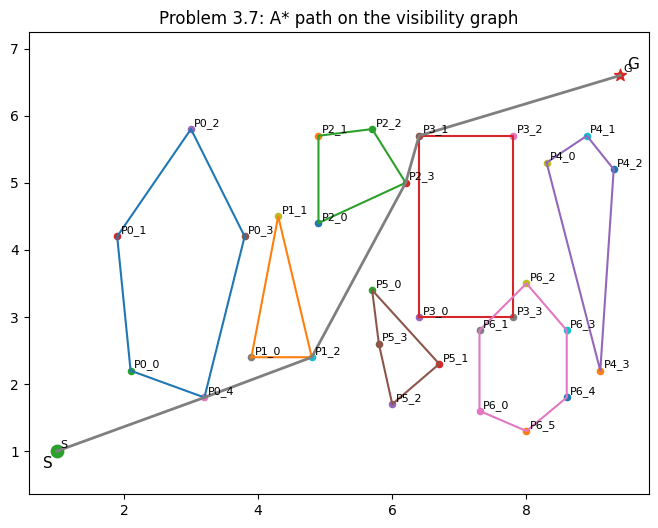

In [ ]:
import matplotlib.pyplot as plt

def draw_scene(path: Optional[List[str]] = None, title: str = "Visibility-graph scene") -> None:
    plt.figure(figsize=(8, 6))
    for poly in polygons:
        xs = [p[0] for p in poly] + [poly[0][0]]
        ys = [p[1] for p in poly] + [poly[0][1]]
        plt.plot(xs, ys)

    for label, point in vertex_points.items():
        plt.scatter(point[0], point[1], s=20)
        plt.text(point[0] + 0.05, point[1] + 0.05, label, fontsize=8)

    if path:
        pts = [vertex_points[s] for s in path]
        plt.plot([p[0] for p in pts], [p[1] for p in pts], linewidth=2)

    plt.scatter(S[0], S[1], s=80, marker="o")
    plt.scatter(G[0], G[1], s=80, marker="*")
    plt.text(S[0] - 0.2, S[1] - 0.25, "S", fontsize=11)
    plt.text(G[0] + 0.1, G[1] + 0.1, "G", fontsize=11)
    plt.axis("equal")
    plt.title(title)
    plt.show()


astar_node, _ = algorithms["A*"]()
draw_scene(reconstruct_states(astar_node), "Problem 3.7: A* path on the visibility graph")

# Problem 3.9 / 3.11 repository numbering: Missionaries and Cannibals

The attached page shows the exact 3rd-edition statement for this problem.

The book asks for analysis of parts **(a)** through **(c)**.

## Problem Definition

Three missionaries and three cannibals are on one river bank with a boat that can carry one or two people. The objective is to move everyone to the other side without ever leaving a group of missionaries outnumbered by cannibals on either bank.

## Concepts Used

This problem uses:
- symbolic state representation
- validity constraints
- state-space graph construction
- repeated-state checking
- breadth-first search for optimality under unit cost

## (a) Problem formulation

A compact state representation is:

(M_L, C_L, B)

where:

- (M_L) = number of missionaries on the left bank
- (C_L) = number of cannibals on the left bank
- B E{0,1}, where `1` means the boat is on the left bank and `0` means the boat is on the right bank

The total numbers are fixed at 3 missionaries and 3 cannibals, so the right bank is determined automatically:

- (M_R = 3 - M_L)
- (C_R = 3 - C_L)

### Validity constraints

A state is valid if:

1. (0 <_ M_L,C_L <_ 3)
2. The boat is on exactly one side
3. On each bank, if missionaries are present, they are not outnumbered by cannibals:
   - (M_L = 0) or (M_L _>C_L)
   - (M_R = 0) or (M_R _> C_R)

### Actions

The boat carries one or two people, so legal boat loads are:

- (2 missionaries)
- (2 cannibals)
- (1 missionary, 1 cannibal)
- (1 missionary)
- (1 cannibal)

Depending on the boat side, an action subtracts those passengers from the departure bank and adds them to the arrival bank.

### Initial and goal states

- Initial: `(3, 3, 1)`
- Goal: `(0, 0, 0)`

This formulation makes only the distinctions needed for a valid solution.

### Complete state space

There are (4*4*2 = 32) syntactically possible tuples.

After removing invalid states, the legal state space is much smaller. The code below generates it exactly.

In [ ]:
boat_loads: List[Tuple[int, int]] = [(2, 0), (0, 2), (1, 1), (1, 0), (0, 1)]

def mc_is_valid(state: State) -> bool:
    m_left, c_left, boat_left = state
    if boat_left not in (0, 1):
        return False
    if not (0 <= m_left <= 3 and 0 <= c_left <= 3):
        return False

    m_right = 3 - m_left
    c_right = 3 - c_left

    left_safe = m_left == 0 or m_left >= c_left
    right_safe = m_right == 0 or m_right >= c_right
    return left_safe and right_safe


def mc_actions(state: State) -> Iterable[Tuple[int, int]]:
    m_left, c_left, boat_left = state
    for m, c in boat_loads:
        if boat_left == 1:
            next_state = (m_left - m, c_left - c, 0)
        else:
            next_state = (m_left + m, c_left + c, 1)

        if mc_is_valid(next_state):
            if 1 <= m + c <= 2:
                yield (m, c)


def mc_result(state: State, action: Tuple[int, int]) -> State:
    m, c = action
    m_left, c_left, boat_left = state
    if boat_left == 1:
        return (m_left - m, c_left - c, 0)
    return (m_left + m, c_left + c, 1)


initial_mc: State = (3, 3, 1)
goal_mc: State = (0, 0, 0)

valid_mc_states = [(m, c, b) for m in range(4) for c in range(4) for b in (0, 1) if mc_is_valid((m, c, b))]
len(valid_mc_states), valid_mc_states

(20,
 [(0, 0, 0),
  (0, 0, 1),
  (0, 1, 0),
  (0, 1, 1),
  (0, 2, 0),
  (0, 2, 1),
  (0, 3, 0),
  (0, 3, 1),
  (1, 1, 0),
  (1, 1, 1),
  (2, 2, 0),
  (2, 2, 1),
  (3, 0, 0),
  (3, 0, 1),
  (3, 1, 0),
  (3, 1, 1),
  (3, 2, 0),
  (3, 2, 1),
  (3, 3, 0),
  (3, 3, 1)])

### Complete state-space graph
The next cells present the valid-state graph in two forms:

1. a **text adjacency list**
2. a **visual diagram** with reachable states separated from valid but unreachable states

This supports the requirement to draw and explain the state space in part **(a)**.

In [ ]:
mc_graph = {state: list(mc_actions(state)) for state in valid_mc_states}

for state in valid_mc_states:
    successors = [mc_result(state, action) for action in mc_graph[state]]
    print(f"{state} -> {successors}")

(0, 0, 0) -> [(0, 2, 1), (1, 1, 1), (0, 1, 1)]
(0, 0, 1) -> []
(0, 1, 0) -> [(0, 3, 1), (1, 1, 1), (0, 2, 1)]
(0, 1, 1) -> [(0, 0, 0)]
(0, 2, 0) -> [(2, 2, 1), (0, 3, 1)]
(0, 2, 1) -> [(0, 0, 0), (0, 1, 0)]
(0, 3, 0) -> []
(0, 3, 1) -> [(0, 1, 0), (0, 2, 0)]
(1, 1, 0) -> [(3, 1, 1), (2, 2, 1)]
(1, 1, 1) -> [(0, 0, 0), (0, 1, 0)]
(2, 2, 0) -> [(3, 3, 1), (3, 2, 1)]
(2, 2, 1) -> [(0, 2, 0), (1, 1, 0)]
(3, 0, 0) -> [(3, 2, 1), (3, 1, 1)]
(3, 0, 1) -> []
(3, 1, 0) -> [(3, 3, 1), (3, 2, 1)]
(3, 1, 1) -> [(1, 1, 0), (3, 0, 0)]
(3, 2, 0) -> [(3, 3, 1)]
(3, 2, 1) -> [(3, 0, 0), (2, 2, 0), (3, 1, 0)]
(3, 3, 0) -> []
(3, 3, 1) -> [(3, 1, 0), (2, 2, 0), (3, 2, 0)]


### Results for the state-space construction

The printed adjacency list above is a complete diagram in text form of the valid state space.

The next cell also draws it visually so that the report and video can show:
- the reachable state-space graph from the start
- the goal state
- valid but unreachable states


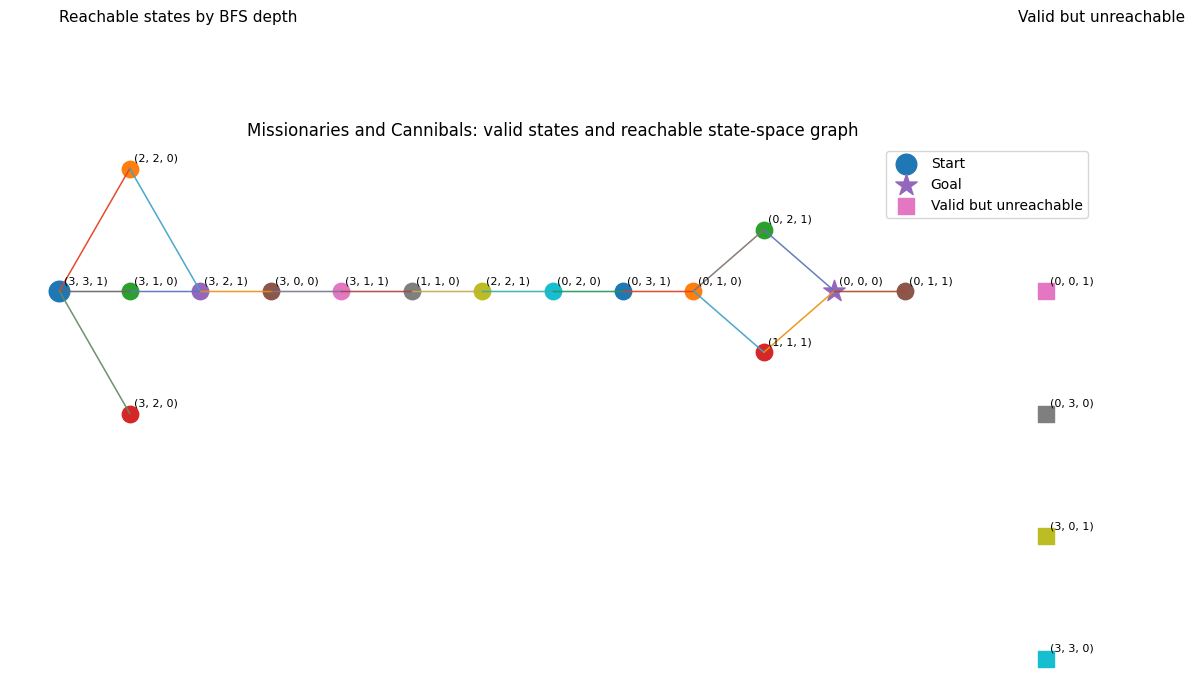

In [ ]:
def bfs_distances(start: State) -> Dict[State, int]:
    q = deque([start])
    dist = {start: 0}

    while q:
        s = q.popleft()
        for action in mc_actions(s):
            t = mc_result(s, action)
            if t not in dist:
                dist[t] = dist[s] + 1
                q.append(t)

    return dist


dist = bfs_distances(initial_mc)

reachable_states = sorted(dist.keys(), key=lambda s: (dist[s], s))
unreachable_states = sorted([s for s in valid_mc_states if s not in dist])

reachable_layers: Dict[int, List[State]] = defaultdict(list)
for state in reachable_states:
    reachable_layers[dist[state]].append(state)

plt.figure(figsize=(14, 7))
positions: Dict[State, Tuple[float, float]] = {}

# Place reachable states by BFS layer.
for layer in sorted(reachable_layers):
    states_in_layer = sorted(reachable_layers[layer])
    n = len(states_in_layer)
    for i, state in enumerate(states_in_layer):
        x = layer
        y = -(i - (n - 1) / 2.0)
        positions[state] = (x, y)

# Places unreachable valid states in a separate labeled column.
unreachable_x = max(reachable_layers.keys()) + 2
for i, state in enumerate(unreachable_states):
    positions[state] = (unreachable_x, -i)

# Draws edges among reachable states.
for state in reachable_states:
    x1, y1 = positions[state]
    for action in mc_actions(state):
        nxt = mc_result(state, action)
        if nxt in positions:
            x2, y2 = positions[nxt]
            plt.plot([x1, x2], [y1, y2], linewidth=1, alpha=0.7)

# Draws nodes.
legend_labels = set()
for state in reachable_states:
    x, y = positions[state]
    if state == initial_mc:
        label = "Start" if "Start" not in legend_labels else None
        plt.scatter(x, y, s=220, marker="o", label=label)
        legend_labels.add("Start")
    elif state == goal_mc:
        label = "Goal" if "Goal" not in legend_labels else None
        plt.scatter(x, y, s=260, marker="*", label=label)
        legend_labels.add("Goal")
    else:
        plt.scatter(x, y, s=140, marker="o")
    plt.text(x + 0.06, y + 0.06, str(state), fontsize=8)

# Draws unreachable valid states differently.
for state in unreachable_states:
    x, y = positions[state]
    label = "Valid but unreachable" if "Valid but unreachable" not in legend_labels else None
    plt.scatter(x, y, s=140, marker="s", label=label)
    legend_labels.add("Valid but unreachable")
    plt.text(x + 0.06, y + 0.06, str(state), fontsize=8)

plt.text(0, 2.2, "Reachable states by BFS depth", fontsize=11)
if unreachable_states:
    plt.text(unreachable_x - 0.4, 2.2, "Valid but unreachable", fontsize=11)

plt.title("Missionaries and Cannibals: valid states and reachable state-space graph")
plt.axis("off")
plt.legend()
plt.show()

## (b) Solve optimally and discuss repeated states

Because every crossing has the same cost in the usual formulation, **BFS** is an appropriate optimal algorithm: it finds the solution with the fewest crossings.

### Why repeated states matter
Repeated states are definitely an issue:
- the boat can undo a move immediately,
- the graph contains many cycles,
- without repeated-state checking, search wastes time revisiting already seen configurations.

So **graph search with an explored set** is a good idea.

In [ ]:
mc_node, mc_stats = breadth_first_graph_search(
    initial_state=initial_mc,
    goal_test=lambda s: s == goal_mc,
    actions=mc_actions,
    result=mc_result,
)

mc_solution = reconstruct_states(mc_node) if mc_node else []
mc_solution, mc_stats

([(3, 3, 1),
  (3, 1, 0),
  (3, 2, 1),
  (3, 0, 0),
  (3, 1, 1),
  (1, 1, 0),
  (2, 2, 1),
  (0, 2, 0),
  (0, 3, 1),
  (0, 1, 0),
  (1, 1, 1),
  (0, 0, 0)],
 {'expanded': 13, 'generated': 15})

In [ ]:
def action_name(action: Tuple[int, int]) -> str:
    m, c = action
    parts = []
    if m:
        parts.append(f"{m}M")
    if c:
        parts.append(f"{c}C")
    return "+".join(parts)

print("Optimal solution:")
for i, node in enumerate(mc_node.path()):
    print(f"Step {i}: {node.state}")
    if i + 1 < len(mc_node.path()):
        print(f"   move {action_name(mc_node.path()[i + 1].action)}")
print()
print("Total crossings:", mc_node.depth)
print("Search stats:", mc_stats)

Optimal solution:
Step 0: (3, 3, 1)
   move 2C
Step 1: (3, 1, 0)
   move 1C
Step 2: (3, 2, 1)
   move 2C
Step 3: (3, 0, 0)
   move 1C
Step 4: (3, 1, 1)
   move 2M
Step 5: (1, 1, 0)
   move 1M+1C
Step 6: (2, 2, 1)
   move 2M
Step 7: (0, 2, 0)
   move 1C
Step 8: (0, 3, 1)
   move 2C
Step 9: (0, 1, 0)
   move 1M
Step 10: (1, 1, 1)
   move 1M+1C
Step 11: (0, 0, 0)

Total crossings: 11
Search stats: {'expanded': 13, 'generated': 15}


### Analysis of part (b)

BFS returns the standard optimal solution in **11 crossings**.

Why BFS is appropriate here:

- every action has equal cost,
- the state graph is small,
- graph search avoids loops,
- BFS is complete and optimal for unit step costs.

So the answer to “Is it a good idea to check for repeated states?” is **yes**.

## (c) Why humans still find the puzzle difficult

Even though the formal state space is small, people often find the puzzle hard because:

1. **The constraints are easy to violate.**  
   A move can look plausible locally but create an illegal state on either bank.

2. **Many tempting moves are reversible dead ends.**  
   Humans often explore by intuition, which causes repeated backtracking.

3. **The boat capacity couples short-term and long-term planning.**  
   A useful move sometimes looks counterproductive because the boat must also be brought back safely.

4. **The problem has hidden structure.**  
   The successful strategy depends on recognizing which return trips preserve safety, not just on moving people across as quickly as possible.

### Lesson learned

A small state space does not always mean a problem feels easy to humans. Formal search methods help because they systematically enforce constraints and avoid repeated mistakes.


# Final conclusions

## Problem 3.7 / 3.9 repository numbering

- **(a)** Continuous positions give an infinite state space and infinitely many paths.
- **(b)** A shortest path can be restricted to **S**, **G**, and obstacle vertices, giving a finite visibility graph.
- **(c)** A suitable search formulation uses visibility neighbors as actions, Euclidean edge costs, and straight-line distance as the heuristic.
- **(d)** In the obstacle domain, **A\*** is the best practical choice among the tested methods: it remains optimal while usually expanding fewer nodes than uniform-cost search.

## Problem 3.9 / 3.11 repository numbering

- **(a)** A precise state is `(M_left, C_left, boat_side)` with safety constraints on both banks.
- **(b)** **BFS with repeated-state checking** solves the problem optimally in 11 crossings.
- **(c)** Humans struggle because the constraints create deceptive local choices and many reversible dead ends.

## Lessons Learned

- Good AI problem solving begins with a clear state representation.
- The same search framework can be adapted to both geometric and symbolic domains.
- Heuristics are especially valuable when they preserve optimality while reducing search effort.
- Repeated-state checking is essential in cyclic problems.

## Credits and References

- Russell, S. and Norvig, P., *Artificial Intelligence: A Modern Approach*.
- AIMA-style search design and Python implementation approach.
- Assignment statement and video guidelines.

## Optional README note

This notebook is self-contained. Run cells from top to bottom in a standard Python 3 Jupyter environment.